## Setup

In [34]:
import time

import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (13, 7)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["figure.dpi"] = 110

STATIC  = "PennAir 2024 App Static.png"
DYNAMIC = "PennAir 2024 App Dynamic.mp4"
HARD    = "PennAir 2024 App Dynamic Hard.mp4"

BUDGET_MS = 1000 / 30   # real-time at 30 fps -- the number to beat on video

## Looking at things

`show` takes any mix of images and measurement maps and puts them in a row.
A BGR uint8 array is drawn as colour; anything single-channel is drawn as
grayscale and auto-scaled to its own range, so a float map with values in
[0, 20] is still visible.  Pass `scale=(lo, hi)` to fix the range instead --
useful when comparing two maps side by side, where auto-scaling would lie.

In [35]:
def show(images, titles=None, scale=None, cols=None):
    """Draw images / maps in a row, inline.

    images : BGR uint8 arrays, or single-channel arrays of any dtype
    titles : optional list of captions
    scale  : (lo, hi) to fix the grayscale range; None auto-scales each map
    cols   : wrap onto multiple rows after this many
    """
    n = len(images)
    cols = cols or n
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, squeeze=False,
                             figsize=(plt.rcParams["figure.figsize"][0],
                                      4.2 * rows))
    for ax in axes.ravel():
        ax.axis("off")
    for i, img in enumerate(images):
        ax = axes.ravel()[i]
        a = np.asarray(img)
        if a.ndim == 3 and a.shape[2] == 3:
            ax.imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
        else:
            lo, hi = scale if scale else (float(a.min()), float(a.max()))
            ax.imshow(a.squeeze(), cmap="gray", vmin=lo, vmax=hi)
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10)
    fig.tight_layout()
    plt.show()


def hist(values, bins=200, log=True, vline=None):
    """Histogram of a measurement map -- for picking a threshold by eye.

    `vline` draws a candidate cutoff on top of it.
    """
    plt.figure(figsize=(9, 3))
    plt.hist(np.asarray(values).ravel(), bins=bins, log=log)
    if vline is not None:
        plt.axvline(vline, color="r", lw=1)
    plt.tight_layout()
    plt.show()

## Getting frames

The video is read one frame at a time, never loaded whole -- the prompt asks
for it to be treated as a stream.  `frame` seeks for convenience while you are
poking at things; `stream` is the honest sequential read, and that is what the
timing cell uses.

In [36]:
def image(path=STATIC):
    """The static image, as BGR uint8."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    return img


def frame(path, index=0):
    """One frame of a video by index.  Convenience for poking around."""
    cap = cv2.VideoCapture(path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, index)
    ok, img = cap.read()
    cap.release()
    if not ok:
        raise IOError(f"could not read frame {index} of {path}")
    return img


def frames(path, count=4):
    """`count` frames spread evenly across a video."""
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out = []
    for i in np.linspace(0, max(total - 2, 0), count).astype(int):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
        ok, img = cap.read()
        if ok:
            out.append(img)
    cap.release()
    return out


def stream(path, count=None, start=0):
    """Yield frames sequentially, one at a time.  No seeking, no lookahead."""
    cap = cv2.VideoCapture(path)
    try:
        for i in range(start):
            if not cap.read()[0]:
                return
        n = 0
        while count is None or n < count:
            ok, img = cap.read()
            if not ok:
                return
            yield img
            n += 1
    finally:
        cap.release()

## Drawing results

Outline in green, centre marked with a red cross and its pixel coordinates.
Independent of how detection works -- it only wants contours.

In [37]:
OUTLINE, CENTER, STATUS = (255, 0, 0), (0, 0, 255), (255, 255, 255)
FONT = cv2.FONT_HERSHEY_SIMPLEX


def centroid(contour):
    """Centre of mass of a contour, or None if it has zero area."""
    m = cv2.moments(contour)
    if m["m00"] == 0:
        return None
    return int(m["m10"] / m["m00"]), int(m["m01"] / m["m00"])


def annotate(img, contours, status=None):
    """Copy of `img` with each contour outlined and its centre marked."""
    vis = img.copy()
    cv2.drawContours(vis, list(contours), -1, OUTLINE, 2, cv2.LINE_AA)
    for contour in contours:
        point = centroid(contour)
        if point is None:
            continue
        cv2.drawMarker(vis, point, CENTER, cv2.MARKER_CROSS, 16, 2, cv2.LINE_AA)
        _text(vis, f"({point[0]}, {point[1]})",
              (point[0] + 12, point[1] - 12), 0.5, CENTER)
    if status:
        _text(vis, status, (12, 34), 0.7, STATUS)
    return vis


def _text(img, s, origin, scale, color):
    # Black pass first, so text stays readable over bright shapes and dark
    # background alike.
    cv2.putText(img, s, origin, FONT, scale, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(img, s, origin, FONT, scale, color, 1, cv2.LINE_AA)

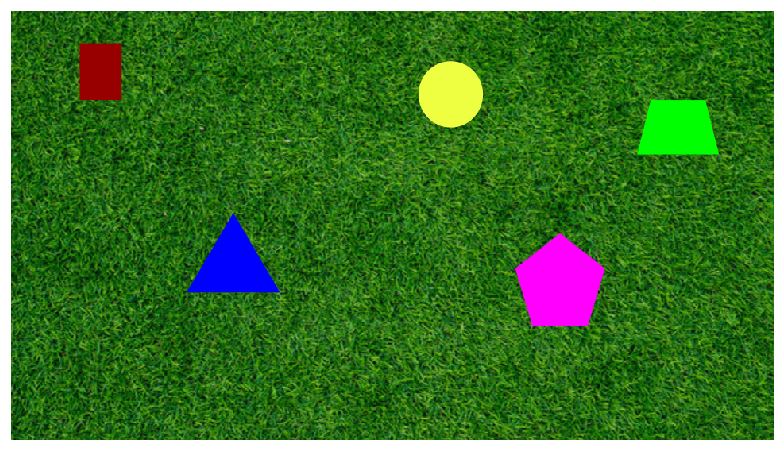

In [38]:
img = image()
show([img])

In [39]:
# measure local variance

K = 15
assert K%2==1

mu  = cv2.boxFilter(img, -1, (K, K))
mu

array([[[ 17, 113,  47],
        [ 17, 113,  47],
        [ 16, 111,  45],
        ...,
        [ 11, 102,  25],
        [ 12, 104,  26],
        [ 12, 105,  26]],

       [[ 17, 114,  47],
        [ 17, 113,  46],
        [ 16, 111,  45],
        ...,
        [ 11, 102,  25],
        [ 12, 103,  26],
        [ 12, 104,  26]],

       [[ 17, 114,  46],
        [ 16, 113,  45],
        [ 16, 111,  44],
        ...,
        [ 12, 102,  25],
        [ 12, 103,  26],
        [ 12, 104,  26]],

       ...,

       [[ 12,  94,  28],
        [ 12,  94,  27],
        [ 12,  94,  27],
        ...,
        [ 12,  98,  33],
        [ 13, 100,  33],
        [ 13, 100,  33]],

       [[ 12,  95,  28],
        [ 12,  94,  27],
        [ 12,  94,  27],
        ...,
        [ 12,  95,  30],
        [ 13,  96,  31],
        [ 13,  97,  31]],

       [[ 12,  95,  28],
        [ 12,  94,  27],
        [ 12,  95,  27],
        ...,
        [ 12,  93,  29],
        [ 13,  95,  30],
        [ 13,  95,  30]]

In [40]:
mu2 = cv2.sqrBoxFilter(img, -1, (K, K))
mu2.shape, mu.shape

((540, 960, 3), (540, 960, 3))

ValueError: 'img' is not a valid value for cmap. Did you mean one of: 'prism', 'magma'?
See `matplotlib.bivar_colormaps()` and `matplotlib.multivar_colormaps()` for bivariate and multivariate colormaps

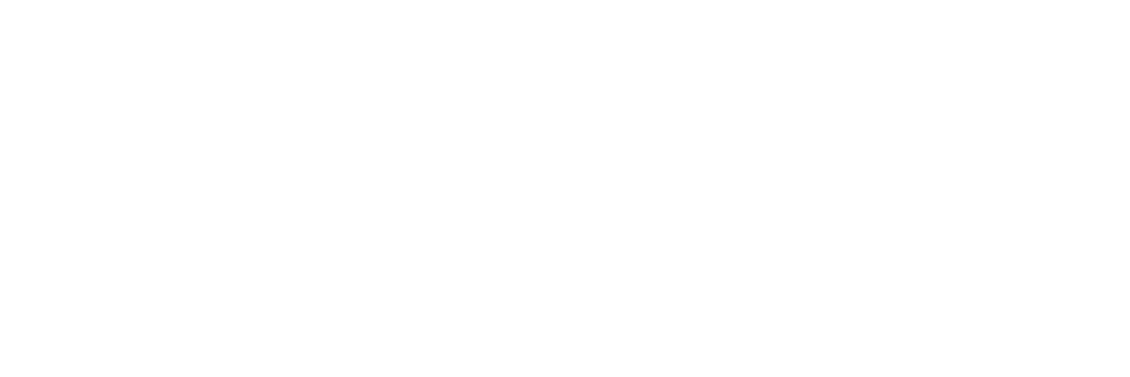

In [42]:
local_variance = mu2 - mu*mu
local_variance = np.sqrt(local_variance.sum(axis=2))
show([local_variance])
hist(local_variance)

In [ ]:
def texture_threshold_contours(image, kernel_size, threshold, area_treshold):
    # plane fit
    K = kernel_size

    mu  = cv2.boxFilter(img, -1, (K, K))
    mu2 = cv2.sqrBoxFilter(img, -1, (K, K))
    local_variance = mu2 - mu*mu
    local_variance = np.clip(local_variance, 0, None)
    local_variance = np.sqrt(local_variance.sum(axis=2))
    std_plane = np.sqrt(local_variance)
    mask = (std_plane < threshold).astype(np.uint8)*255
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cnts_filtered = [c for c in cnts if cv2.contourArea(c) > area_treshold]

    return cnts_filtered

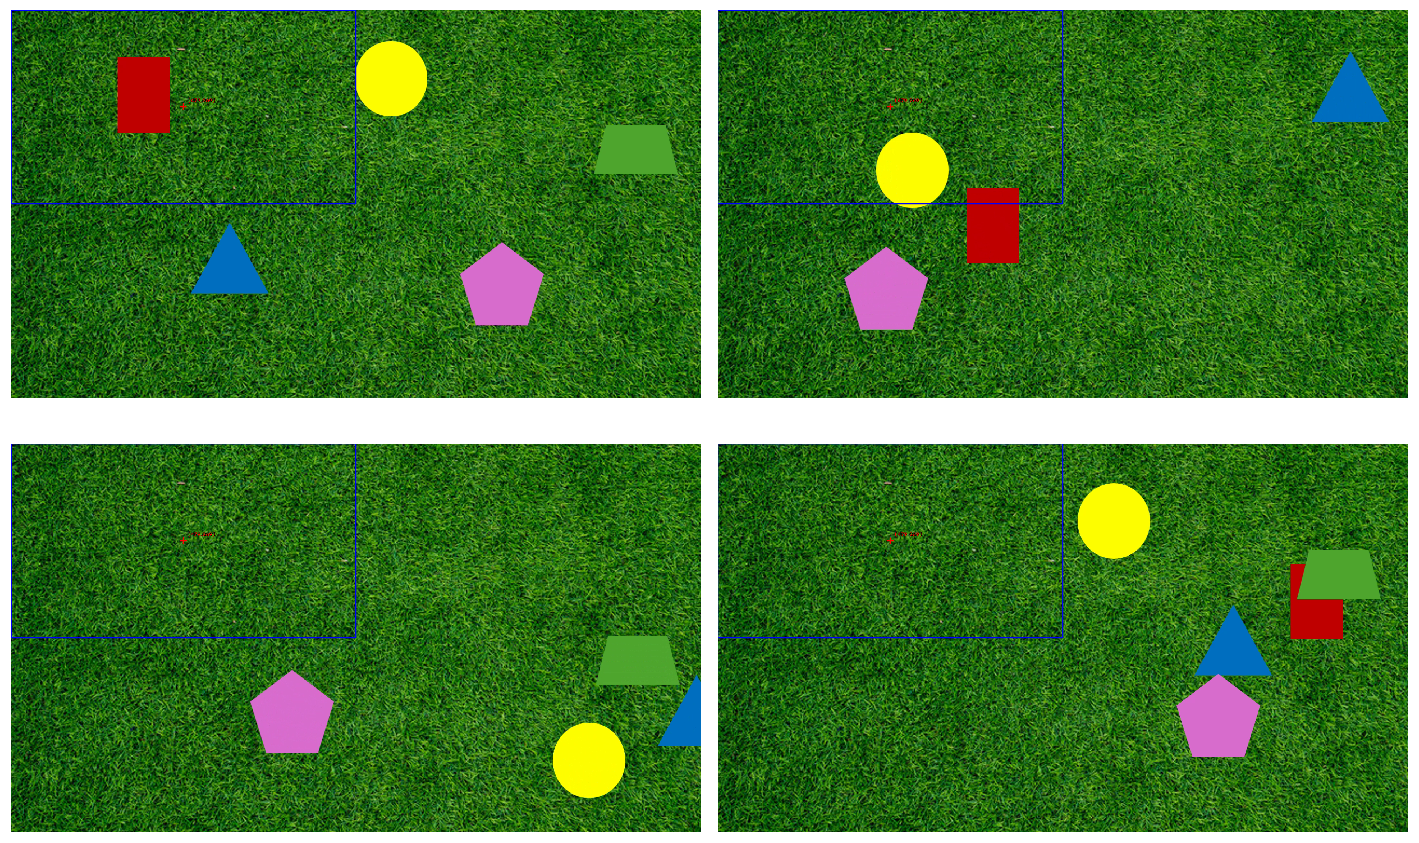

In [43]:
images_hard = frames("PennAir 2024 App Dynamic.mp4")
show([annotate(img, texture_threshold_contours(img, 5, 100, 1e3)) for img in images_hard], cols=2)

ValueError: 'img' is not a valid value for cmap. Did you mean one of: 'prism', 'magma'?
See `matplotlib.bivar_colormaps()` and `matplotlib.multivar_colormaps()` for bivariate and multivariate colormaps

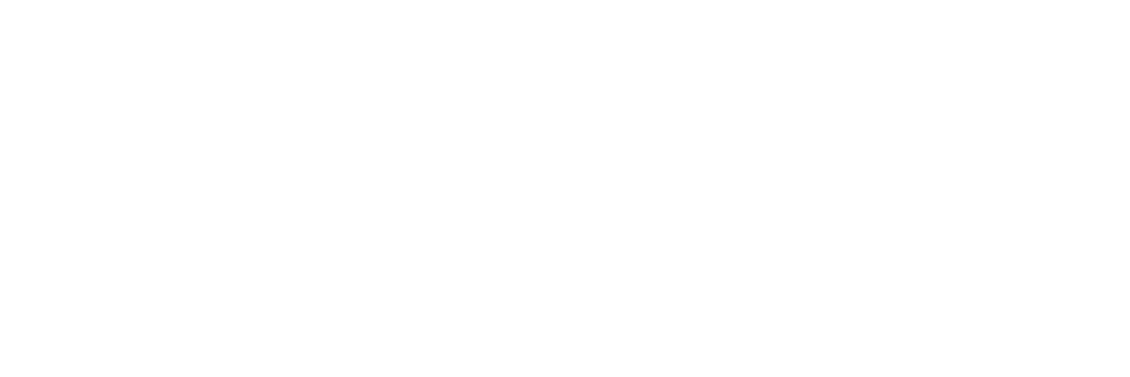

In [44]:
img = image()
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)/255

show([img])

# measure local variance

K = 15
assert K%2==1

mu  = cv2.boxFilter(img, -1, (K, K))
mu